<a href="https://colab.research.google.com/github/falyseck/Multimodel_Data_Prepocessing/blob/main/notebooks/data_merge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

social_url = "https://raw.githubusercontent.com/falyseck/Multimodel_Data_Prepocessing/main/data/raw/customer_info/customer_social_profiles.csv"
transactions_url = "https://raw.githubusercontent.com/falyseck/Multimodel_Data_Prepocessing/main/data/raw/customer_info/customer_transactions.csv"

social_df = pd.read_csv(social_url)
transactions_df = pd.read_csv(transactions_url)

# Quick check
print(social_df.head())
print(transactions_df.head())

  customer_id_new social_media_platform  engagement_score  \
0            A178              LinkedIn                74   
1            A190               Twitter                82   
2            A150              Facebook                96   
3            A162               Twitter                89   
4            A197               Twitter                92   

   purchase_interest_score review_sentiment  
0                      4.9         Positive  
1                      4.8          Neutral  
2                      1.6         Positive  
3                      2.6         Positive  
4                      2.3          Neutral  
   customer_id_legacy  transaction_id  purchase_amount purchase_date  \
0                 151            1001              408    2024-01-01   
1                 192            1002              332    2024-01-02   
2                 114            1003              442    2024-01-03   
3                 171            1004              256    2024-01-04 

### Dataset Info

In [ ]:
print("Social Profiles:")
print(social_df.info())

print("\nTransactions:")
print(transactions_df.info())

Social Profiles:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id_new          155 non-null    object 
 1   social_media_platform    155 non-null    object 
 2   engagement_score         155 non-null    int64  
 3   purchase_interest_score  155 non-null    float64
 4   review_sentiment         155 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 6.2+ KB
None

Transactions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id_legacy  150 non-null    int64  
 1   transaction_id      150 non-null    int64  
 2   purchase_amount     150 non-null    int64  
 3   purchase_date       150 non-null    object 
 4   product_category

### Descriptive Statistics

In [ ]:
print("Social Profiles Descriptive Statistics:")
print(social_df.describe())

print("\nSocial Profiles Info:")
print(social_df.info())

Social Profiles Descriptive Statistics:
       engagement_score  purchase_interest_score
count        155.000000               155.000000
mean          75.606452                 3.152903
std           14.568021                 1.142867
min           50.000000                 1.000000
25%           63.500000                 2.350000
50%           77.000000                 3.200000
75%           87.500000                 4.100000
max           99.000000                 5.000000

Social Profiles Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id_new          155 non-null    object 
 1   social_media_platform    155 non-null    object 
 2   engagement_score         155 non-null    int64  
 3   purchase_interest_score  155 non-null    float64
 4   review_sentiment         155 non-null    object 
dtypes: float6

## Visualize Distributions and Outliers for Numerical Columns in `social_df`

Histograms and box plots for `engagement_score` and `purchase_interest_score` in `social_df` to visualize their distributions and identify potential outliers.

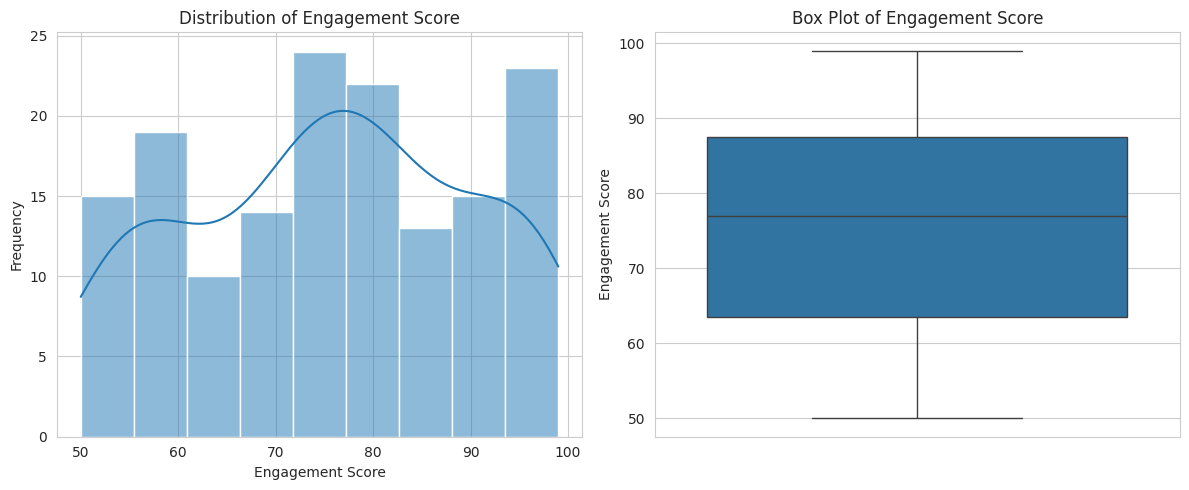

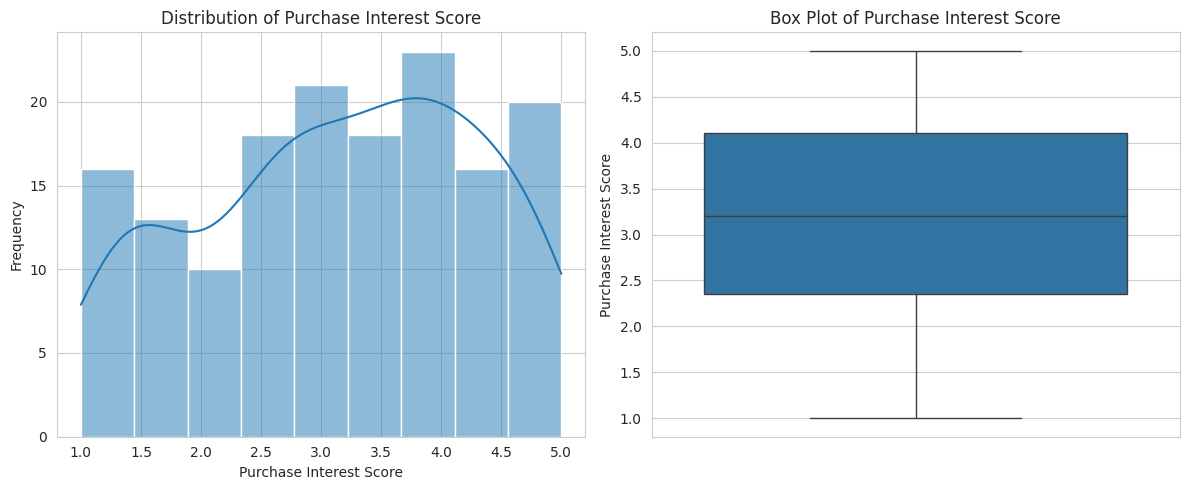

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
sns.set_style("whitegrid")

# Create subplots for engagement_score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(social_df['engagement_score'], kde=True)
plt.title('Distribution of Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=social_df['engagement_score'])
plt.title('Box Plot of Engagement Score')
plt.ylabel('Engagement Score')

plt.tight_layout()
plt.show()

# Create subplots for purchase_interest_score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(social_df['purchase_interest_score'], kde=True)
plt.title('Distribution of Purchase Interest Score')
plt.xlabel('Purchase Interest Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=social_df['purchase_interest_score'])
plt.title('Box Plot of Purchase Interest Score')
plt.ylabel('Purchase Interest Score')

plt.tight_layout()
plt.show()

## Visualize Distributions and Outliers for Numerical Columns in `transactions_df`


Histograms and box plots for `purchase_amount` and `customer_rating` in `transactions_df` to visualize their distributions and identify potential outliers.

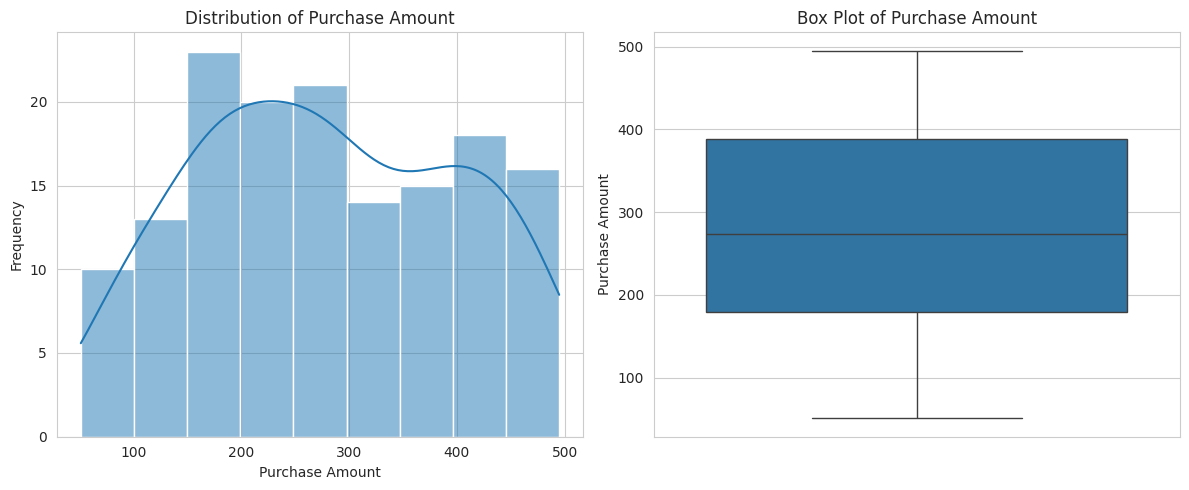

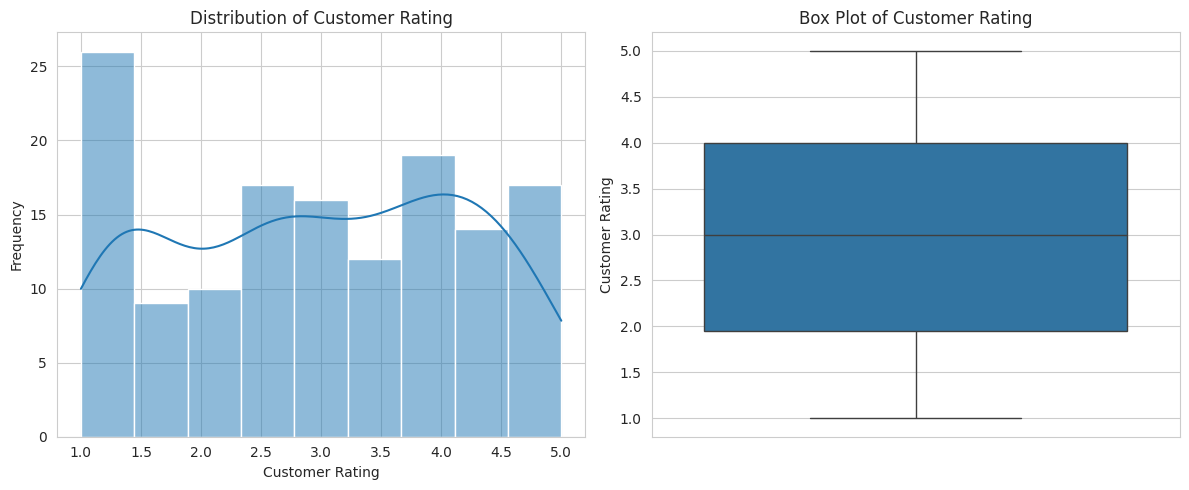

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style (if not already set)
sns.set_style("whitegrid")

# Create subplots for purchase_amount
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(transactions_df['purchase_amount'], kde=True)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=transactions_df['purchase_amount'])
plt.title('Box Plot of Purchase Amount')
plt.ylabel('Purchase Amount')

plt.tight_layout()
plt.show()

# Create subplots for customer_rating
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(transactions_df['customer_rating'].dropna(), kde=True) # Drop NaNs for histogram
plt.title('Distribution of Customer Rating')
plt.xlabel('Customer Rating')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=transactions_df['customer_rating'])
plt.title('Box Plot of Customer Rating')
plt.ylabel('Customer Rating')

plt.tight_layout()
plt.show()

## Visualize social_df Correlations


Correlation matrix heatmap for the numerical columns in `social_df` (`engagement_score`, `purchase_interest_score`) to understand the relationships between variables.


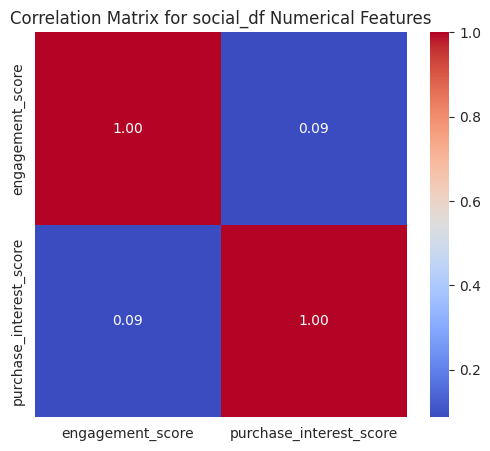

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns from social_df
correlation_data_social = social_df[['engagement_score', 'purchase_interest_score']]

# Calculate the correlation matrix
correlation_matrix_social = correlation_data_social.corr()

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_social, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for social_df Numerical Features')
plt.show()

## Visualize transactions_df Correlations

Correlation matrix heatmap for the relevant numerical columns in `transactions_df` (`purchase_amount`, `customer_rating`) to understand the relationships between variables.

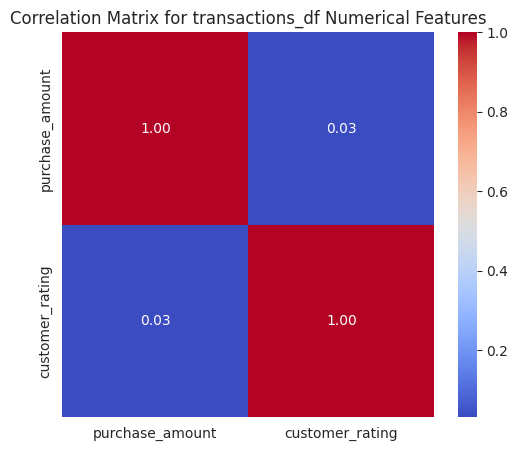

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns from transactions_df
correlation_data_transactions = transactions_df[['purchase_amount', 'customer_rating']]

# Calculate the correlation matrix
correlation_matrix_transactions = correlation_data_transactions.corr()

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_transactions, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for transactions_df Numerical Features')
plt.show()

## Visualize Correlations for Numerical Columns

Correlation heatmap for the numerical columns (`engagement_score`, `purchase_interest_score`, `purchase_amount`, `customer_rating`) to identify relationships between these features.

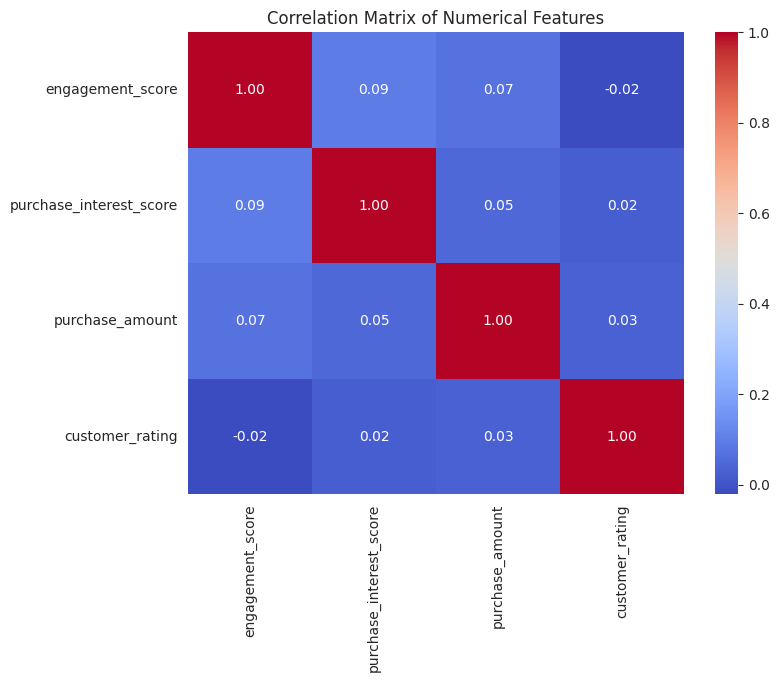

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select numerical columns from both dataframes
# These are already available in temp_df_correlation.
# We will use temp_df_correlation, but need to handle NaNs as per merged_df logic.

correlation_data = temp_df_correlation.copy() # Use a copy to avoid modifying temp_df_correlation directly if it's used elsewhere

# Handle NaNs in customer_rating first, as it was done for merged_df
# The mean should be calculated on the existing non-null customer_rating values
correlation_data['customer_rating'] = correlation_data['customer_rating'].fillna(correlation_data['customer_rating'].mean())

# Drop any remaining rows with NaNs
# This accounts for the rows that became NaN due to the concat of dataframes with different lengths
correlation_data = correlation_data.dropna()

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Summary of Key Findings

**1. Descriptive Statistics and Data Types:**
*   **social_df:** Contains 155 entries with no missing values. Columns include `customer_id_new` (object), `social_media_platform` (object), `engagement_score` (int64), `purchase_interest_score` (float64), and `review_sentiment` (object). `engagement_score` ranges from 50 to 99 with a mean of 75.6. `purchase_interest_score` ranges from 1.0 to 5.0 with a mean of 3.15.
*   **transactions_df:** Contains 150 entries. `customer_rating` has 10 missing values (140 non-null out of 150), while other columns are complete. Columns include `customer_id_legacy` (int64), `transaction_id` (int64), `purchase_amount` (int64), `purchase_date` (object), `product_category` (object), and `customer_rating` (float64). `purchase_amount` ranges from 51 to 495 with a mean of 280.78. `customer_rating` ranges from 1.0 to 5.0 with a mean of 2.98.

**2. Distributions and Outliers:**
*   **social_df:**
    *   `engagement_score`: The distribution appears to be somewhat bell-shaped, slightly skewed towards higher scores. The box plot shows no significant outliers.
    *   `purchase_interest_score`: The distribution seems relatively uniform across its range, indicating a spread of interest levels. No significant outliers were identified.
*   **transactions_df:**
    *   `purchase_amount`: The distribution is fairly spread out and uniform across its range, suggesting a variety of purchase amounts without strong centralization. The box plot indicates no extreme outliers.
    *   `customer_rating`: The distribution appears somewhat uniform, with ratings spread across the 1-5 scale. No obvious outliers are present.

**3. Correlations:**
*   **social_df (engagement_score vs. purchase_interest_score):** The correlation coefficient is very low (approximately 0.09), suggesting almost no linear relationship between a customer's engagement score on social media and their purchase interest score.
*   **transactions_df (purchase_amount vs. customer_rating):** The correlation coefficient is extremely low (approximately 0.03), indicating a negligible linear relationship between the amount of a purchase and the customer's rating for that transaction.
*   **Combined Numerical Features:** When looking at the combined numerical features (`engagement_score`, `purchase_interest_score`, `purchase_amount`, `customer_rating`), all pairwise correlations are very close to zero. This implies that these features are largely independent of each other. For instance, high social media engagement or purchase interest does not strongly predict higher purchase amounts or customer ratings, and vice versa.

Since the IDs are not matching, we merge by row order

In [ ]:
social_df = social_df.reset_index(drop=True)
transactions_df = transactions_df.reset_index(drop=True)

In [ ]:
# Concatenate side by side
merged_df = pd.concat([social_df, transactions_df], axis=1)

# Drop the legacy ID column to avoid confusion
merged_df = merged_df.drop(columns=['customer_id_legacy'])

# Rename new ID column for consistency
merged_df = merged_df.rename(columns={'customer_id_new': 'customer_id'})

print("Merged Dataset Preview:")
display(merged_df.head())

Merged Dataset Preview:


,customer_id,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,A178,LinkedIn,74,4.9,Positive,1001.0,408.0,2024-01-01,Sports,2.3
1,A190,Twitter,82,4.8,Neutral,1002.0,332.0,2024-01-02,Electronics,4.2
2,A150,Facebook,96,1.6,Positive,1003.0,442.0,2024-01-03,Electronics,2.1
3,A162,Twitter,89,2.6,Positive,1004.0,256.0,2024-01-04,Clothing,2.8
4,A197,Twitter,92,2.3,Neutral,1005.0,64.0,2024-01-05,Clothing,1.3


In [ ]:
merged_df.isnull().sum()

,0
customer_id,0
social_media_platform,0
engagement_score,0
purchase_interest_score,0
review_sentiment,0
transaction_id,5
purchase_amount,5
purchase_date,5
product_category,5
customer_rating,15


Handling missing values

In [ ]:

# Fill customer_rating if missing
merged_df['customer_rating'] = merged_df['customer_rating'].fillna(merged_df['customer_rating'].mean())

# drop  remaining rows with NaNs
merged_df = merged_df.dropna()

In [ ]:
merged_df.isnull().sum()

,0
customer_id,0
social_media_platform,0
engagement_score,0
purchase_interest_score,0
review_sentiment,0
transaction_id,0
purchase_amount,0
purchase_date,0
product_category,0
customer_rating,0


Saving merged csv file

In [ ]:
output_path = "merged_customer_data.csv"
merged_df.to_csv(output_path, index=False)
print("✅ Merged dataset saved to", output_path)
print("Shape:", merged_df.shape)

✅ Merged dataset saved to merged_customer_data.csv
Shape: (150, 20)
